In [ ]:
# repo-root bootstrap — relative data/ paths resolve from any kernel cwd
import os, pathlib
_root = pathlib.Path.cwd()
while not (_root / 'pyproject.toml').exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
print('cwd ->', _root)

# Tracking Scientific Drift in NLP via Atomic Contribution Claims

#### Processed-Paper Statistics

Claim extraction is performed in `extraction.ipynb`

In [2]:
import os
import pandas as pd

START_YEAR = 2020
END_YEAR = 2025
ANALYSIS_YEARS = [START_YEAR, END_YEAR]

CLAIMS_FILE = 'data/claims/openrouter_claims.csv'

if not os.path.exists(CLAIMS_FILE):
    raise FileNotFoundError(f"Claims file was not found: {CLAIMS_FILE}")


def print_project_stats():
    raw_file = 'data/raw/emnlp_papers_raw.csv'

    if not os.path.exists(raw_file):
        print(f"Error: File {raw_file} was not found.")
        return

    df_raw = pd.read_csv(raw_file)
    df_raw['abs_len'] = df_raw['abstract'].fillna('').str.len()

    if os.path.exists(CLAIMS_FILE):
        df_claims = pd.read_csv(CLAIMS_FILE)

        claims_per_paper = df_claims.groupby('paper_id').size().reset_index(name='claims_count')
        processed_ids = set(df_claims['paper_id'].unique())
        df_raw['is_processed'] = df_raw['paper_id'].isin(processed_ids)

        df_stats = pd.merge(df_raw, claims_per_paper, on='paper_id', how='left')
        df_stats['claims_count'] = df_stats['claims_count'].fillna(0)
    else:
        print(f"Warning: File {CLAIMS_FILE} was not found.")
        df_raw['is_processed'] = False
        df_stats = df_raw.copy()
        df_stats['claims_count'] = 0

    yearly_stats = df_stats.groupby('year').agg(
        total_papers=('paper_id', 'count'),
        processed_papers=('is_processed', 'sum'),
        avg_abstract_len=('abs_len', 'mean'),
        avg_claims_per_paper=('claims_count', lambda x: x[df_stats.loc[x.index, 'is_processed']].mean())
    ).reset_index()

    print("=== OVERALL PROJECT STATISTICS ===")
    print(f"Total papers in corpus: {len(df_raw)}")
    print(f"Endpoint years: {START_YEAR} -> {END_YEAR}")

    if os.path.exists(CLAIMS_FILE):
        print(f"Claims source file: {CLAIMS_FILE}")
        print(f"Total extracted claims: {len(df_claims)}")
        print(f"Total unique processed papers: {len(processed_ids)}")

        if 'provider' in df_claims.columns and 'model_name' in df_claims.columns:
            print("\nExtraction source breakdown:")
            src = df_claims[['provider', 'model_name']].value_counts().reset_index(name='claims')
            print(src.to_string(index=False))

    print("\nYear-by-year breakdown:")

    formatted_table = yearly_stats.copy()
    formatted_table['progress'] = (
        formatted_table['processed_papers'] / formatted_table['total_papers'] * 100
    ).round(1).astype(str) + '%'
    formatted_table['avg_abstract_len'] = formatted_table['avg_abstract_len'].round(1)
    formatted_table['avg_claims_per_paper'] = formatted_table['avg_claims_per_paper'].round(2).fillna(0)

    columns_to_show = [
        'year', 'total_papers', 'processed_papers', 'progress',
        'avg_abstract_len', 'avg_claims_per_paper'
    ]
    print(formatted_table[columns_to_show].to_string(index=False))


print_project_stats()

=== OVERALL PROJECT STATISTICS ===
Total papers in corpus: 6517
Endpoint years: 2020 -> 2025
Claims source file: extraction_results/openrouter_claims.csv
Total extracted claims: 18293
Total unique processed papers: 4937

Extraction source breakdown:
  provider                         model_name  claims
openrouter qwen/qwen3-235b-a22b-thinking-2507   18293

Year-by-year breakdown:
 year  total_papers  processed_papers progress  avg_abstract_len  avg_claims_per_paper
 2020           751               748    99.6%            1009.9                  3.58
 2021           847               844    99.6%            1070.1                  3.52
 2022           826               823    99.6%            1127.8                  3.72
 2023          1047               849    81.1%            1154.8                  3.66
 2024          1237               829    67.0%            1165.4                  3.71
 2025          1809               844    46.7%            1194.5                  4.03


In [3]:
import pandas as pd

START_YEAR = globals().get('START_YEAR', 2020)
END_YEAR = globals().get('END_YEAR', 2025)
ANALYSIS_YEARS = globals().get('ANALYSIS_YEARS', [START_YEAR, END_YEAR])
CLAIMS_FILE = globals().get('CLAIMS_FILE', 'data/claims/openrouter_claims.csv')
BALANCED_SAMPLE_YEARS = list(range(START_YEAR, END_YEAR + 1))
TARGET_PAPERS_PER_YEAR = 748
BALANCE_RANDOM_SEED = 42

df_claims = pd.read_csv(CLAIMS_FILE)
print(f"Loaded {len(df_claims)} claims from {CLAIMS_FILE}.")

required_cols = {'paper_id', 'year', 'original_title', 'atomic_claim'}
missing = required_cols - set(df_claims.columns)
if missing:
    raise ValueError(f"Claims file is missing required columns: {sorted(missing)}")

df_claims['year'] = pd.to_numeric(df_claims['year'], errors='coerce')
invalid_year_rows = int(df_claims['year'].isna().sum())
if invalid_year_rows:
    print(f"Dropping {invalid_year_rows} rows with non-numeric year values.")
df_claims = df_claims[df_claims['year'].notna()].copy()
df_claims['year'] = df_claims['year'].astype(int)

def balance_claims_by_year(df, years, target_papers_per_year, random_seed=42):
    df = df[df['year'].isin(years)].copy()
    sampled_papers = []

    for year in years:
        year_papers = (
            df.loc[df['year'] == year, 'paper_id']
            .dropna()
            .drop_duplicates()
            .sort_values()
        )
        available_papers = len(year_papers)
        if available_papers < target_papers_per_year:
            raise ValueError(
                f"Year {year} has only {available_papers} unique papers, cannot sample {target_papers_per_year}."
            )

        year_sample = year_papers.sample(n=target_papers_per_year, random_state=random_seed)
        sampled_papers.append(pd.DataFrame({'paper_id': year_sample.values, 'year': year}))

    sampled_papers = pd.concat(sampled_papers, ignore_index=True)
    df = df.merge(sampled_papers, on=['paper_id', 'year'], how='inner')

    balance_summary = (
        df.groupby('year')
        .agg(papers=('paper_id', 'nunique'), claims=('atomic_claim', 'size'))
        .reindex(years)
    )
    print('Balanced claims subset by year:')
    print(balance_summary.to_string())
    return df

df_claims = balance_claims_by_year(
    df_claims,
    years=BALANCED_SAMPLE_YEARS,
    target_papers_per_year=TARGET_PAPERS_PER_YEAR,
    random_seed=BALANCE_RANDOM_SEED,

)

years_available = sorted(df_claims['year'].unique().tolist())
if years_available:
    print(f"Available years in claims: {years_available[0]}..{years_available[-1]} ({len(years_available)} years)")
else:
    print('Warning: no valid year values found after cleaning.')

USE_TITLES = False  # If True, embed title + claim; if False, embed claim text only.

Loaded 18293 claims from extraction_results/openrouter_claims.csv.
Balanced claims subset by year:
      papers  claims
year                
2020     748    2678
2021     748    2606
2022     748    2791
2023     748    2738
2024     748    2762
2025     748    3001
Available years in claims: 2020..2025 (6 years)


### Embedding

#### Vector Representation with SPECTER2

I use SPECTER2 because it is highly specialized for scientific text and trained with citation-based similarity objectives. It should capture close semantic equivalence between formulations such as "Large Language Model" and "Generative Pre-trained Transformer".

https://huggingface.co/allenai/specter2 — using the `proximity` version recommended for general embedding, link prediction, and nearest-neighbor search.

We use https://huggingface.co/allenai/specter2_aug2023refresh, which is refreshed on newer papers.

We embed ACCs directly (instead of `Title + [SEP] + Abstract`) to avoid forcing all claims from the same paper into one semantic region.

In [4]:
import torch
import numpy as np
from tqdm import tqdm
from transformers import AutoTokenizer
from adapters import AutoAdapterModel

model_name = "allenai/specter2_aug2023refresh_base"
adapter_id = "allenai/specter2_aug2023refresh"

print(f"Loading SPECTER 2 Base: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoAdapterModel.from_pretrained(model_name)

print(f"Loading Proximity Adapter: {adapter_id}")
model.load_adapter(adapter_id, source="hf", load_as="specter2", set_active=True)
print("Loaded adapters:", model.adapters_config.adapters.keys())
print("Active adapters:", model.active_adapters)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

# Batch processing function
def get_embeddings(titles, claims, batch_size=16):
    all_embeddings = []
    
    # If flag is on: Pair title + claim for every row
    if USE_TITLES:
        text_batch = [t + tokenizer.sep_token + c for t,c in zip(titles, claims)]
    else:
        text_batch = [c for t,c in zip(titles, claims)]
    
    for i in tqdm(range(0, len(text_batch), batch_size), desc="Embedding batches"):
        batch_texts = text_batch[i:i + batch_size]
        
        inputs = tokenizer(
            batch_texts, 
            padding=True, 
            truncation=True, 
            return_tensors="pt", 
            return_token_type_ids=False, # Explicitly disabled as per official docs
            max_length=512
        ).to(device)
        
        with torch.no_grad():
            output = model(**inputs)
        
        # take the first token in the batch as the embedding, as authors recommend
        embeddings = output.last_hidden_state[:, 0, :]
        all_embeddings.append(embeddings.cpu().numpy())
        
    return np.vstack(all_embeddings)

<repo>\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading SPECTER 2 Base: allenai/specter2_aug2023refresh_base
Loading Proximity Adapter: allenai/specter2_aug2023refresh


Fetching 4 files: 100%|██████████| 4/4 [00:00<?, ?it/s]
There are adapters available but none are activated for the forward pass.


Loaded adapters: dict_keys(['specter2'])
Active adapters: Stack[specter2]


In [5]:
# Execution
print("Generating embeddings...")
titles = df_claims['original_title'].astype(str).tolist()
claims = df_claims['atomic_claim'].astype(str).tolist()

embeddings = get_embeddings(titles, claims, batch_size=32)

print(f"Embedding shape: {embeddings.shape}")

Generating embeddings...


Embedding batches: 100%|██████████| 518/518 [05:25<00:00,  1.59it/s]

Embedding shape: (16576, 768)


### UMAP

First, reduce to 5D to preserve structure for clustering, then reduce to 2D for visualization and downstream inspection.

Reference: McInnes et al., UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction.

In [6]:
import umap
import warnings
warnings.filterwarnings('ignore') # Suppress numba warnings

# UMAP 5D projection
print("Running UMAP (5 components for clustering)...")
umap_5d = umap.UMAP(
    n_neighbors=40, 
    n_components=5, 
    min_dist=0.0,
    metric='cosine', 
    random_state=42
).fit_transform(embeddings)

# Project to 2D for Visualization
print("Running UMAP (2 components for visualization)...")
umap_2d = umap.UMAP(
    n_neighbors=40, 
    n_components=2, 
    min_dist=0.5, 
    metric='cosine', 
    random_state=42
).fit_transform(embeddings)

df_claims['x'] = umap_2d[:, 0]
df_claims['y'] = umap_2d[:, 1]

Running UMAP (5 components for clustering)...
Running UMAP (2 components for visualization)...


#### HDBSCAN + TF-IDF

Using an extended stop-word list with additional abstract-specific high-frequency terms.

In [ ]:
import hdbscan
from acc.cluster import compute_descriptors


print("Clustering with HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom'
)
df_claims['cluster'] = clusterer.fit_predict(umap_5d)

# Cluster naming via acc.cluster -- the single source of truth for the naming
# methodology: class-based c-TF-IDF (each cluster = one document) over the
# claim-level vocabulary, with hyphen-aware tokens, a claim-level min_df floor,
# class-IDF, a coverage filter, and a snowball+canon lemmatising de-duplicator
# (containment + per-stem cap). See src/acc/cluster.py and CLUSTER_LABEL_REVIEW.md.
# compute_descriptors returns a short (top-3) and full (top-5) descriptor per
# cluster; cluster_name stores the short one (curated names live in
# config.READABLE_LABELS and are resolved by short_label / full_label).
print("Generating cluster labels (c-TF-IDF, acc.cluster)...")
desc = compute_descriptors(df_claims)
cluster_names = {-1: 'noise'}
cluster_names.update({cid: short for cid, (short, _full) in desc.items()})
df_claims['cluster_name'] = df_claims['cluster'].map(cluster_names)

print(df_claims[['cluster', 'cluster_name']].drop_duplicates().head(10))

cluster_size_map = df_claims['cluster'].value_counts().to_dict()
df_claims['cluster_size'] = df_claims['cluster'].map(cluster_size_map)
cluster_summary = (
    df_claims[['cluster', 'cluster_name', 'cluster_size']]
    .drop_duplicates()
    .sort_values(by='cluster_size', ascending=False)
)
print("\nSample clusters found (sorted by size):")
print(cluster_summary.head(10))


### Cluster Analysis

#### Random Claims from the Largest Clusters

In [8]:
# Cluster inspection
N_clusters=5

# Filter out noise (-1) and count cluster sizes
valid_clusters = df_claims[df_claims['cluster'] != -1]
top_n_clusters = valid_clusters['cluster'].value_counts().head(N_clusters)

print(f"INSPECTING TOP {N_clusters} LARGEST CLUSTERS\n")

for cluster_id, count in top_n_clusters.items():
    # Get the cluster name (taking the first occurrence as they are all the same)
    cluster_name = valid_clusters[valid_clusters['cluster'] == cluster_id]['cluster_name'].iloc[0]
    
    # Get 4 random samples (handling cases where cluster < 4 just in case)
    cluster_subset = valid_clusters[valid_clusters['cluster'] == cluster_id]
    sample_size = min(4, len(cluster_subset))
    samples = cluster_subset.sample(n=sample_size, random_state=42)['atomic_claim'].tolist()
    
    print(f"Cluster ID: {cluster_id}")
    print(f"Name: {cluster_name}")
    print(f"Size: {count} claims")
    print("Random Samples:")
    for i, claim in enumerate(samples, 1):
        print(f"  {i}. {claim}")
    print("-" * 50 + "\n")

INSPECTING TOP 5 LARGEST CLUSTERS

Cluster ID: 56
Name: speculative, pruning, heads
Size: 1085 claims
Random Samples:
  1. ScalingFilter is equivalent to an inverse utilization of scaling laws.
  2. SALAM improves LLM accuracy on two challenging frameworks.
  3. Three lightweight adaptations to the utility function in Minimum Bayes Risk decoding improve structural optimality.
  4. MTAdam balances the gradient magnitudes of multiple loss terms in a layer-specific and time-dynamic manner.
--------------------------------------------------

Cluster ID: 6
Name: vision, video, captions
Size: 990 claims
Random Samples:
  1. VideoCLIP pre-trains a unified model for zero-shot video and text understanding without using labels on downstream tasks.
  2. MoSE combines modality-split predictions using ensemble methods with weights that model modality importance dynamically during multimodal knowledge graph completion inference.
  3. 3D Relative Position Multi-head Attention (3DRP-MA) focuses on lan

#### Claim-to-Abstract Comparison

In [9]:
RAW_ABSTRACTS_FILE = 'data/raw/emnlp_papers_raw.csv'
HAS_RAW = os.path.exists(RAW_ABSTRACTS_FILE)
if not (HAS_RAW):
    print('[skipped] data/raw/emnlp_papers_raw.csv not shipped in the public bundle — see README §Data')
else:
    import pandas as pd

    # Display settings
    N_clusters = 5      # Number of top clusters to inspect
    N_samples = 2       # Number of claim examples per cluster
    MAX_ABS_LEN = 300   # Max abstract snippet length for readability

    # 1. Load source abstracts
    df_raw = pd.read_csv('data/raw/emnlp_papers_raw.csv')[['paper_id', 'abstract']]

    # 2. Merge claims with abstracts by paper_id
    df_rich = pd.merge(df_claims, df_raw, on='paper_id', how='left')

    # 3. Exclude noise (-1) and keep largest clusters
    valid_clusters = df_rich[df_rich['cluster'] != -1]
    top_n_clusters = valid_clusters['cluster'].value_counts().head(N_clusters)

    print(f"=== INSPECTING TOP {N_clusters} LARGEST THEMES ===\n")

    for cluster_id, count in top_n_clusters.items():
        # Cluster label
        cluster_name = valid_clusters[valid_clusters['cluster'] == cluster_id]['cluster_name'].iloc[0]
    
        # Random sample of claims
        cluster_subset = valid_clusters[valid_clusters['cluster'] == cluster_id]
        sample_size = min(N_samples, len(cluster_subset))
        samples = cluster_subset.sample(n=sample_size, random_state=42)
    
        print(f"CLUSTER ID: {cluster_id}")
        print(f"NAME: {cluster_name}")
        print(f"SIZE: {count} claims")
        print(f"\nRANDOM SAMPLES ({sample_size}):")
    
        for i, (_, row) in enumerate(samples.iterrows(), 1):
            # Short abstract preview
            abstract_snippet = row['abstract']
            if len(abstract_snippet) > MAX_ABS_LEN:
                abstract_snippet = abstract_snippet[:MAX_ABS_LEN] + "..."
            
            print(f"  {i}. CLAIM: {row['atomic_claim']}")
            print(f"     SOURCE TITLE: {row['original_title']}")
            print(f"     ABSTRACT: {abstract_snippet}")
            print(f"     ---")
        
        print("=" * 80 + "\n")

=== INSPECTING TOP 5 LARGEST THEMES ===

CLUSTER ID: 56
NAME: speculative, pruning, heads
SIZE: 1085 claims

RANDOM SAMPLES (2):
  1. CLAIM: ScalingFilter is equivalent to an inverse utilization of scaling laws.
     SOURCE TITLE: ScalingFilter: Assessing Data Quality through Inverse Utilization of Scaling Laws
     ABSTRACT: High-quality data is crucial for the pre-training performance of large language models. Unfortunately, existing quality filtering methods rely on a known high-quality dataset as reference, which can introduce potential bias and compromise diversity. In this paper, we propose ScalingFilter, a novel a...
     ---
  2. CLAIM: SALAM improves LLM accuracy on two challenging frameworks.
     SOURCE TITLE: Learning from Mistakes via Cooperative Study Assistant for Large Language Models
     ABSTRACT: Large language models (LLMs) have demonstrated their potential to refine their generation based on their own feedback. However, the feedback from LLM itself is often inaccur

#### Cluster Composition and Temporal Shift

In [10]:
# Share of claims by cluster in top themes
print("=== CLUSTER COMPOSITION IN TOP THEMES ===\n")

for cluster_id in top_n_clusters.index:
    cluster_data = valid_clusters[valid_clusters['cluster'] == cluster_id]
    cluster_name = cluster_data['cluster_name'].iloc[0]

    year_counts = cluster_data.groupby('year').size().sort_index()
    total_claims = int(year_counts.sum())

    print(f"CLUSTER ID: {cluster_id} - {cluster_name} (Total claims: {total_claims})")
    for year, count in year_counts.items():
        pct = round(count / total_claims * 100, 1) if total_claims > 0 else 0.0
        print(f"  {year}: {count} claims ({pct}%)")
    print("-" * 80 + "\n")

=== CLUSTER COMPOSITION IN TOP THEMES ===

CLUSTER ID: 56 - speculative, pruning, heads (Total claims: 1085)
  2020: 135 claims (12.4%)
  2021: 189 claims (17.4%)
  2022: 178 claims (16.4%)
  2023: 169 claims (15.6%)
  2024: 164 claims (15.1%)
  2025: 250 claims (23.0%)
--------------------------------------------------------------------------------

CLUSTER ID: 6 - vision, video, captions (Total claims: 990)
  2020: 86 claims (8.7%)
  2021: 94 claims (9.5%)
  2022: 161 claims (16.3%)
  2023: 160 claims (16.2%)
  2024: 220 claims (22.2%)
  2025: 269 claims (27.2%)
--------------------------------------------------------------------------------

CLUSTER ID: 11 - dialogue, dialogues, dialog (Total claims: 756)
  2020: 175 claims (23.1%)
  2021: 176 claims (23.3%)
  2022: 111 claims (14.7%)
  2023: 167 claims (22.1%)
  2024: 71 claims (9.4%)
  2025: 56 claims (7.4%)
--------------------------------------------------------------------------------

CLUSTER ID: 43 - translation, ssa, machine

In [11]:
def endpoint_paper_totals(df, start_year=START_YEAR, end_year=END_YEAR):
    total_start = df[df['year'] == start_year]['paper_id'].nunique()
    total_end = df[df['year'] == end_year]['paper_id'].nunique()
    return total_start, total_end


def endpoint_claim_totals(df, start_year=START_YEAR, end_year=END_YEAR):
    total_start = int((df['year'] == start_year).sum())
    total_end = int((df['year'] == end_year).sum())
    return total_start, total_end


def endpoint_year_counts(df, by='cluster_name', value_col='paper_id', agg='nunique',
                         start_year=START_YEAR, end_year=END_YEAR):
    if agg == 'size':
        counts = df.groupby([by, 'year']).size().unstack(fill_value=0)
    else:
        counts = df.groupby([by, 'year'])[value_col].nunique().unstack(fill_value=0)

    counts = counts.reindex(columns=[start_year, end_year], fill_value=0)
    counts.columns = [f'count_{start_year}', f'count_{end_year}']
    return counts

In [12]:
# Cluster-level paper-document frequency change between endpoint years
print(f"=== CLUSTER DF CHANGE ({START_YEAR} vs {END_YEAR}) ===\n")

total_start, total_end = endpoint_paper_totals(df_claims, START_YEAR, END_YEAR)

for cluster_id in top_n_clusters.index:
    cluster_data = valid_clusters[valid_clusters['cluster'] == cluster_id]
    cluster_name = cluster_data['cluster_name'].iloc[0]

    c_start = set(cluster_data[cluster_data['year'] == START_YEAR]['paper_id'])
    c_end = set(cluster_data[cluster_data['year'] == END_YEAR]['paper_id'])

    df_start = (len(c_start) / total_start * 100) if total_start else 0.0
    df_end = (len(c_end) / total_end * 100) if total_end else 0.0
    delta = df_end - df_start

    print(f"CLUSTER ID: {cluster_id} - {cluster_name}")
    print(f"  {START_YEAR} DF: {df_start:.2f}% ({len(c_start)} papers)")
    print(f"  {END_YEAR} DF: {df_end:.2f}% ({len(c_end)} papers)")
    print(f"  Delta  : {delta:+.2f} pp")
    print("-" * 80 + "\n")

=== CLUSTER DF CHANGE (2020 vs 2025) ===

CLUSTER ID: 56 - speculative, pruning, heads
  2020 DF: 10.03% (75 papers)
  2025 DF: 17.51% (131 papers)
  Delta  : +7.49 pp
--------------------------------------------------------------------------------

CLUSTER ID: 6 - vision, video, captions
  2020 DF: 4.28% (32 papers)
  2025 DF: 13.37% (100 papers)
  Delta  : +9.09 pp
--------------------------------------------------------------------------------

CLUSTER ID: 11 - dialogue, dialogues, dialog
  2020 DF: 8.02% (60 papers)
  2025 DF: 3.88% (29 papers)
  Delta  : -4.14 pp
--------------------------------------------------------------------------------

CLUSTER ID: 43 - translation, ssa, machine
  2020 DF: 6.28% (47 papers)
  2025 DF: 1.87% (14 papers)
  Delta  : -4.41 pp
--------------------------------------------------------------------------------

CLUSTER ID: 78 - pruning, cmr, blank
  2020 DF: 3.34% (25 papers)
  2025 DF: 8.56% (64 papers)
  Delta  : +5.21 pp
-------------------------

In [13]:
# Most year-concentrated clusters among top themes
print("=== MOST YEAR-CONCENTRATED CLUSTERS ===\n")

rows = []
for cluster_id in top_n_clusters.index:
    cluster_data = valid_clusters[valid_clusters['cluster'] == cluster_id]
    cluster_name = cluster_data['cluster_name'].iloc[0]
    year_share = cluster_data['year'].value_counts(normalize=True)

    if year_share.empty:
        continue

    dominant_year = int(year_share.index[0])
    concentration = float(year_share.iloc[0])
    rows.append((cluster_id, cluster_name, dominant_year, concentration, len(cluster_data)))

rows = sorted(rows, key=lambda x: x[3], reverse=True)
for cluster_id, cluster_name, dominant_year, concentration, n_claims in rows:
    print(f"CLUSTER ID: {cluster_id} - {cluster_name}")
    print(f"  Dominant year: {dominant_year}")
    print(f"  Concentration: {concentration * 100:.1f}% of claims")
    print(f"  Total claims : {n_claims}")
    print("-" * 80 + "\n")

=== MOST YEAR-CONCENTRATED CLUSTERS ===

CLUSTER ID: 78 - pruning, cmr, blank
  Dominant year: 2024
  Concentration: 31.5% of claims
  Total claims : 467
--------------------------------------------------------------------------------

CLUSTER ID: 6 - vision, video, captions
  Dominant year: 2025
  Concentration: 27.2% of claims
  Total claims : 990
--------------------------------------------------------------------------------

CLUSTER ID: 43 - translation, ssa, machine
  Dominant year: 2020
  Concentration: 24.6% of claims
  Total claims : 476
--------------------------------------------------------------------------------

CLUSTER ID: 11 - dialogue, dialogues, dialog
  Dominant year: 2021
  Concentration: 23.3% of claims
  Total claims : 756
--------------------------------------------------------------------------------

CLUSTER ID: 56 - speculative, pruning, heads
  Dominant year: 2025
  Concentration: 23.0% of claims
  Total claims : 1085
----------------------------------------

In [14]:
# Shows three random examples for each cluster across all clusters
print("=== EXAMPLE CLAIMS FROM ALL CLUSTERS ===\n")

for cluster_id in sorted(valid_clusters['cluster'].unique()):
    cluster_data = valid_clusters[valid_clusters['cluster'] == cluster_id]
    cluster_name = cluster_data['cluster_name'].iloc[0]

    print(f"CLUSTER ID: {cluster_id} - {cluster_name} (Total Claims: {len(cluster_data)})")

    sample_size = min(3, len(cluster_data))
    samples = cluster_data.sample(n=sample_size, random_state=42)['atomic_claim'].tolist()
    for idx, claim in enumerate(samples, 1):
        print(f"  Example {idx}: {claim}")

    print("-" * 80 + "\n")

=== EXAMPLE CLAIMS FROM ALL CLUSTERS ===

CLUSTER ID: 0 - coreference, resolution, signed (Total Claims: 54)
  Example 1: Two self-supervised tasks improve mention representation for coreference resolution.
  Example 2: Model size, amount of supervision, and choice of sequence representations are key factors for coreference resolution performance.
  Example 3: A seq2seq model that generates only tagged spans achieves high performance for coreference resolution.
--------------------------------------------------------------------------------

CLUSTER ID: 1 - aspect, opinion, sentiment (Total Claims: 183)
  Example 1: Sentiment-driven simplified clauses are important for sentiment classification.
  Example 2: Incorporating latent graphs improves aspect sentiment classification performance.
  Example 3: Combining out-of-distribution detection with time series modeling enhances models' capability to adapt to evolving temporal distribution shifts in financial sentiment analysis in volatile 

In [15]:
if not (HAS_RAW):
    print('[skipped] depends on data/raw abstracts (absent in the public bundle) — see README §Data')
else:
    # 10 random examples from the noise cluster (-1)
    print("=== EXAMPLE CLAIMS FROM NOISE CLUSTER (-1) ===\n")
    noise_cluster = df_rich[df_rich['cluster'] == -1]
    print(f"Total claims in noise cluster: {len(noise_cluster)}")

    if noise_cluster.empty:
        print("No noise claims found.")
    else:
        examples = noise_cluster.sample(n=min(10, len(noise_cluster)), random_state=42)
        for i, claim in enumerate(examples['atomic_claim'].tolist(), 1):
            print(f"  Example {i}: {claim}")

=== EXAMPLE CLAIMS FROM NOISE CLUSTER (-1) ===

Total claims in noise cluster: 5980
  Example 1: Many natural-language prompts have corresponding 'evil twins' that are unintelligible to humans but provably elicit similar behavior in language models.
  Example 2: Existing multimodal large language models have advantages and limitations for weather and climate event forecasting.
  Example 3: LLMs disproportionately recommend luxury gifts for individuals in high-income countries.
  Example 4: Models pretrained at scale on English pretraining corpora are not truly monolingual.
  Example 5: IBKD preserves important learned information and avoids unnecessary information in text representation models, reducing the risk of over-fitting.
  Example 6: RE2 facilitates bidirectional encoding in unidirectional decoder-only Large Language Models by using the first pass to provide global information for the second pass.
  Example 7: Synthetic multilingual data generation for safety classification inc

### Figures

In [16]:
n_abstracts = df_claims['original_title'].nunique()

#### Butterfly Plot

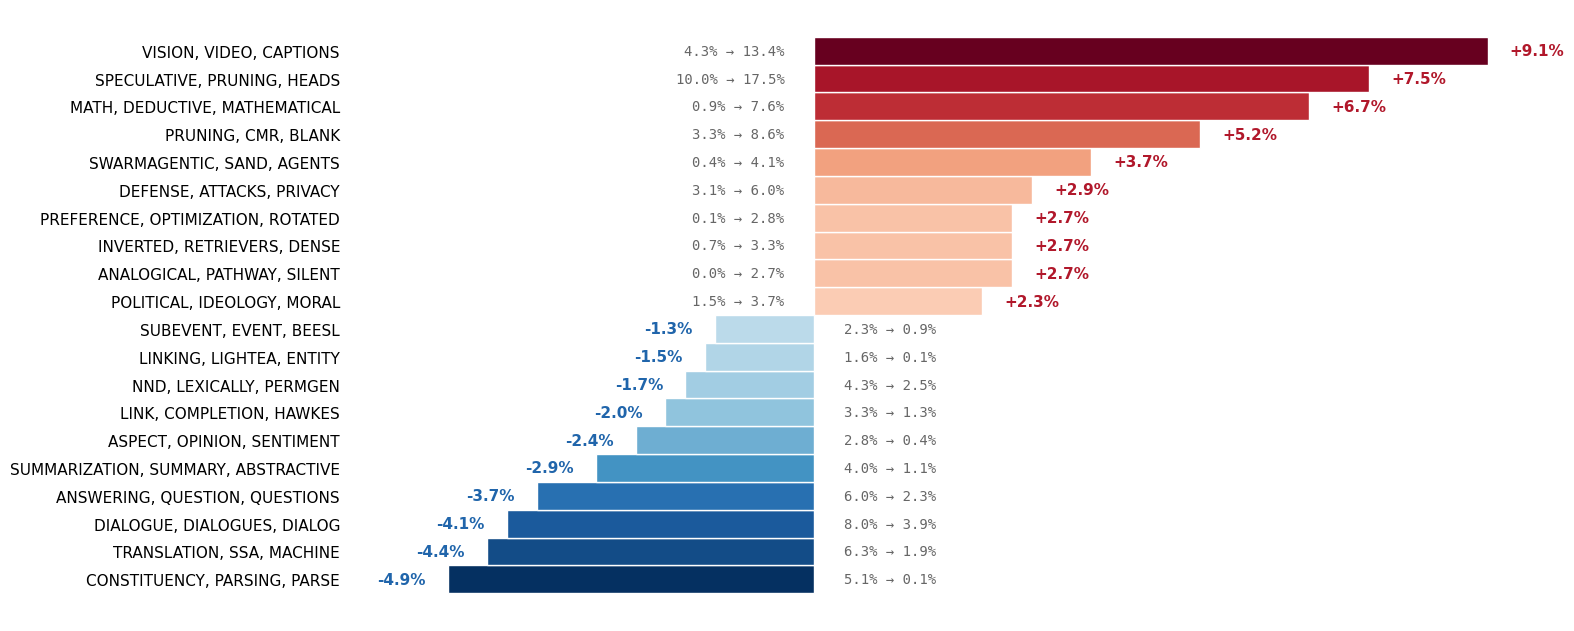

In [18]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- CONFIGURATION ---
CMAP_NAME = 'RdBu_r'
TOP_N = 10
Y_AXIS_PAD = 40

# 1. PREPARE DATA
df_clean = df_claims[df_claims['cluster'] != -1].copy()
total_papers_start, total_papers_end = endpoint_paper_totals(df_claims, START_YEAR, END_YEAR)

counts = endpoint_year_counts(
    df_clean,
    by='cluster_name',
    value_col='paper_id',
    agg='nunique',
    start_year=START_YEAR,
    end_year=END_YEAR,
    )
counts['pct_start'] = (counts[f'count_{START_YEAR}'] / total_papers_start * 100) if total_papers_start else 0.0
counts['pct_end'] = (counts[f'count_{END_YEAR}'] / total_papers_end * 100) if total_papers_end else 0.0
counts['delta'] = counts['pct_end'] - counts['pct_start']

counts['shift_label'] = counts.apply(
    lambda x: f"{x['pct_start']:.1f}% → {x['pct_end']:.1f}%", axis=1
)

drift_sorted = counts.sort_values('delta', ascending=True)
plot_data = pd.concat([drift_sorted.head(TOP_N), drift_sorted.tail(TOP_N)])

clean_index = [
    x.replace('_', ' ').replace('-', ' ').upper().strip()
    for x in plot_data.index
]
plot_data.index = clean_index

# 2. SETUP PLOT
fig, ax = plt.subplots(figsize=(13, 9))

norm = mcolors.TwoSlopeNorm(vmin=plot_data['delta'].min(), vcenter=0, vmax=plot_data['delta'].max())
cmap = plt.get_cmap(CMAP_NAME)
colors = [cmap(norm(val)) for val in plot_data['delta']]

bars = ax.barh(plot_data.index, plot_data['delta'], color=colors, height=1.0, edgecolor='white', linewidth=1)

# 3. STYLING
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.tick_params(axis='y', length=0, labelsize=11, pad=Y_AXIS_PAD)

# 4. LABELS
for bar, value, shift_text in zip(bars, plot_data['delta'], plot_data['shift_label']):
    width = bar.get_width()
    delta_text = f"{value:+.1f}%"
    text_color = cmap(0.1) if value < 0 else cmap(0.9)
    grey_text = '#666666'

    if value < 0:
        ax.text(
            width - 0.3, bar.get_y() + bar.get_height() / 2, delta_text,
            va='center', ha='right', fontsize=11, fontweight='bold', color=text_color
        )
        ax.text(
            0.4, bar.get_y() + bar.get_height() / 2, shift_text,
            va='center', ha='left', fontsize=10, color=grey_text, family='monospace'
        )
    else:
        ax.text(
            width + 0.3, bar.get_y() + bar.get_height() / 2, delta_text,
            va='center', ha='left', fontsize=11, fontweight='bold', color=text_color
        )
        ax.text(
            -0.4, bar.get_y() + bar.get_height() / 2, shift_text,
            va='center', ha='right', fontsize=10, color=grey_text, family='monospace'
        )

plt.subplots_adjust(top=0.7, bottom=0.02, left=0.1, right=0.98)
plt.savefig('artifacts/drift_chart_butterfly.pdf', format='pdf', dpi=300, bbox_inches='tight', pad_inches=0.01)
plt.show()

#### Growth Table

In [20]:
import numpy as np
import pandas as pd

# --- CONFIGURATION ---
TOP_N = 10
MIN_SHARE_THRESHOLD = 0.5

# 1. PREPARE DATA (Same pipeline)
df_clean = df_claims[df_claims['cluster'] != -1].copy()
total_papers_start, total_papers_end = endpoint_paper_totals(df_claims, START_YEAR, END_YEAR)

counts = endpoint_year_counts(
    df_clean,
    by='cluster_name',
    value_col='paper_id',
    agg='nunique',
    start_year=START_YEAR,
    end_year=END_YEAR,
    )
counts['pct_start'] = (counts[f'count_{START_YEAR}'] / total_papers_start * 100) if total_papers_start else 0.0
counts['pct_end'] = (counts[f'count_{END_YEAR}'] / total_papers_end * 100) if total_papers_end else 0.0

counts = counts[
    (counts['pct_start'] >= MIN_SHARE_THRESHOLD) |
    (counts['pct_end'] >= MIN_SHARE_THRESHOLD)
] .copy()

counts['growth_rate'] = ((counts['pct_end'] - counts['pct_start']) / (counts['pct_start'] + 0.001)) * 100

clean_index = [x.replace('_', ' ').replace('-', ' ').title().strip() for x in counts.index]
counts.index = clean_index

growth_df = counts[counts['growth_rate'] > 0].sort_values('growth_rate', ascending=False).head(TOP_N)
decline_df = counts[counts['growth_rate'] < 0].sort_values('growth_rate', ascending=True).head(TOP_N)

rows_to_render = min(TOP_N, len(growth_df), len(decline_df))

# --- GENERATE LATEX TABLE ---
print(r"""
\begin{table*}[t]
\centering
\small
\begin{tabular}{lrr|lrr}
\toprule
\multicolumn{3}{c}{\textbf{Fading Themes (Top Decline)}} & \multicolumn{3}{c}{\textbf{Rising Stars (Top Growth)}} \\
\cmidrule(r){1-3} \cmidrule(l){4-6}
\textbf{Semantic Cluster} & \textbf{Share '20$\to$'25} & \textbf{$\Delta$\%} & \textbf{Semantic Cluster} & \textbf{Share '20$\to$'25} & \textbf{$\Delta$\%} \\
\midrule""")

for i in range(rows_to_render):
    d_name = decline_df.index[i]
    if len(d_name) > 28:
        d_name = d_name[:26] + '..'

    d_share = f"{decline_df.iloc[i]['pct_start']:.1f}\% $\to$ {decline_df.iloc[i]['pct_end']:.1f}\%"
    d_rate = decline_df.iloc[i]['growth_rate']
    d_rate_str = f"\\textbf{{{d_rate:.0f}\%}}"

    g_name = growth_df.index[i]
    if len(g_name) > 28:
        g_name = g_name[:26] + '..'

    g_share = f"{growth_df.iloc[i]['pct_start']:.1f}\% $\to$ {growth_df.iloc[i]['pct_end']:.1f}\%"
    g_rate = growth_df.iloc[i]['growth_rate']
    g_rate_str = f"\\textbf{{+{g_rate:,.0f}\%}}"

    print(f"{d_name} & {d_share} & {d_rate_str} & {g_name} & {g_share} & {g_rate_str} \\\\")

print(r"""\bottomrule
\end{tabular}
\caption{\label{tab:drift_stats} The ``Scientific Drift'' of EMNLP (2020--2025). We list the top declining and emerging semantic clusters based on relative change in publication volume. Topics are filtered for relevance ($>0.5\%$ share in at least one endpoint year).}
\end{table*}
""")


\begin{table*}[t]
\centering
\small
\begin{tabular}{lrr|lrr}
\toprule
\multicolumn{3}{c}{\textbf{Fading Themes (Top Decline)}} & \multicolumn{3}{c}{\textbf{Rising Stars (Top Growth)}} \\
\cmidrule(r){1-3} \cmidrule(l){4-6}
\textbf{Semantic Cluster} & \textbf{Share '20$\to$'25} & \textbf{$\Delta$\%} & \textbf{Semantic Cluster} & \textbf{Share '20$\to$'25} & \textbf{$\Delta$\%} \\
\midrule
Keyphrase, Keyphrases, One.. & 0.8\% $	o$ 0.0\% & \textbf{-100\%} & Analogical, Pathway, Silent & 0.0\% $	o$ 2.7\% & \textbf{+267,380\%} \\
Style, Sneuron, Tst & 0.7\% $	o$ 0.0\% & \textbf{-100\%} & Molecular, Molecule, Molec.. & 0.0\% $	o$ 0.9\% & \textbf{+93,583\%} \\
Autoregressive, Lat, Rewri.. & 0.5\% $	o$ 0.0\% & \textbf{-100\%} & Hallucination, Hallucinati.. & 0.0\% $	o$ 0.8\% & \textbf{+80,214\%} \\
Constituency, Parsing, Parse & 5.1\% $	o$ 0.1\% & \textbf{-97\%} & Toxicity, Detoxification, .. & 0.0\% $	o$ 0.7\% & \textbf{+66,845\%} \\
Linking, Lightea, Entity & 1.6\% $	o$ 0.1\% & \textbf{-92\

#### Multi-Year Stacked Area (Top-10 Clusters)

In [21]:
import numpy as np
import plotly.graph_objects as go

df_non_noise = df_claims[df_claims['cluster'] != -1].copy()
yearly_papers = df_non_noise.groupby('year')['paper_id'].nunique().sort_index()

ts_counts = (
    df_non_noise.groupby(['year', 'cluster_name'])['paper_id']
    .nunique()
    .reset_index(name='paper_count')
)

ts_counts['year_total'] = ts_counts['year'].map(yearly_papers)
ts_counts['df_pct'] = np.where(
    ts_counts['year_total'] > 0,
    ts_counts['paper_count'] / ts_counts['year_total'] * 100,
    0.0,
    )

# Select stable top clusters by cumulative document frequency across 2020..2025.
focus_years = list(range(START_YEAR, END_YEAR + 1))
ts_focus = ts_counts[ts_counts['year'].isin(focus_years)].copy()
top_clusters = (
    ts_focus.groupby('cluster_name')['df_pct']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

plot_df = ts_focus[ts_focus['cluster_name'].isin(top_clusters)].copy()
plot_df = plot_df.sort_values(['year', 'cluster_name'])

fig = go.Figure()
for cluster_name in top_clusters:
    sub = plot_df[plot_df['cluster_name'] == cluster_name]
    fig.add_trace(
        go.Scatter(
            x=sub['year'],
            y=sub['df_pct'],
            mode='lines',
            stackgroup='one',
            name=cluster_name,
            hovertemplate='Year %{x}<br>DF %{y:.2f}%<extra></extra>',
        )
    )

fig.update_layout(
    title='Top-10 Cluster Share Dynamics (Stacked DF, 2020-2025)',
    xaxis_title='Year',
    yaxis_title='Document Frequency Share (%)',
    hovermode='x unified',
    template='plotly_white',
)
fig.show()

In [22]:
# Claim-level statistic: number of unique abstracts per year
abstract_counts = df_claims.groupby('year')['paper_id'].nunique()
print("Number of unique abstracts per year:")
print(abstract_counts)

Number of unique abstracts per year:


year
2020    748
2021    748
2022    748
2023    748
2024    748
2025    748
Name: paper_id, dtype: int64


## Validation

### SToP

In [23]:
STOP_TAXONOMY_FILE = 'data/external/STop_topic_classification_dataset_for_scientific_papers.csv'
HAS_STOP = os.path.exists(STOP_TAXONOMY_FILE)
if not (HAS_STOP):
    print('[skipped] data/external SToP taxonomy not shipped in the public bundle — see README §Data')
else:
    import pandas as pd
    import numpy as np
    import re

    # 1. Load SToP
    stop_df = pd.read_csv('data/external/STop_topic_classification_dataset_for_scientific_papers.csv')

    # 2. Normalize titles for exact matching
    def norm_title(t):
        if not isinstance(t, str):
            return ''
        return re.sub(r'[^a-z0-9 ]', '', t.lower().strip())

    stop_df['title_norm'] = stop_df['Paper Name'].map(norm_title)
    df_claims['title_norm'] = df_claims['original_title'].map(norm_title)

    # 3. Build mapping title_norm -> set(labels) and map to claims
    stop_labels = {title: frozenset(g['Labels'].dropna().unique()) for title, g in stop_df.groupby('title_norm')}
    df_claims['stop_labels'] = df_claims['title_norm'].map(stop_labels)

    # Keep only claims that matched SToP
    df_val = df_claims[df_claims['stop_labels'].notna()].copy()

    print("Matching complete.")
    print(f"SToP papers matched in current sample: {df_val['paper_id'].nunique()}")
    print(f"Claims with ground-truth labels: {len(df_val)}")

Matching complete.
SToP papers matched in current sample: 653
Claims with ground-truth labels: 2356


In [24]:
if not (HAS_STOP):
    print('[skipped] depends on data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # All conferences in SToP
    print("\nConferences represented in SToP:")
    print(stop_df['Conference'].value_counts())


Conferences represented in SToP:
Conference
ACL2020         705
EMNLP2020       681
ACLJCNLP2021    470
NAACL_2021      394
EACL2021        295
Name: count, dtype: int64


In [25]:
if not (HAS_STOP):
    print('[skipped] depends on data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # Top topics in SToP
    print("\nTop topics in SToP:")
    display(stop_df['Labels'].value_counts())


Top topics in SToP:


Labels
Machine Learning for NLP                                                  259
Machine Translation and Multilinguality                                   258
Information Extraction                                                    216
Dialogue and Interactive Systems                                          201
Semantics: Sentence-level Semantics, Textual Inference and Other areas    184
Interpretability and Analysis of Models for NLP                           173
Generation                                                                152
Question Answering                                                        143
Sentiment Analysis, Stylistic Analysis, and Argument Mining               126
Resources and Evaluation                                                  112
Summarization                                                             111
Language Grounding to Vision, Robotics and Beyond                         100
Computational Social Science and Social Media            

In [26]:
if not (HAS_STOP):
    print('[skipped] depends on data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # Replace the original topic names with the shortened ones in df_val 
    topic_mapping = {
        "Machine Learning for NLP": "ML for NLP",
        "Machine Translation and Multilinguality": "MT & Multilinguality",
        "Information Extraction": "Information Extraction",
        "Dialogue and Interactive Systems": "Dialogue Systems",
        "Semantics: Sentence-level Semantics, Textual Inference and Other areas": "Semantics",
        "Interpretability and Analysis of Models for NLP": "Model Interpretability",
        "Generation": "Generation",
        "Question Answering": "Question Answering",
        "Sentiment Analysis, Stylistic Analysis, and Argument Mining": "Sentiment & Argument Mining",
        "Resources and Evaluation": "Resources & Evaluation",
        "Summarization": "Summarization",
        "Language Grounding to Vision, Robotics and Beyond": "Grounding & Robotics",
        "Computational Social Science and Social Media": "Social Science & Social Media",
        "Information Retrieval and Text Mining": "IR & Text Mining",
        "Semantics: Lexical Semantics": "Lexical Semantics",
        "Syntax: Tagging, Chunking and Parsing": "Syntax & Parsing",
        "Speech and Multimodality": "Speech & Multimodality",
        "Linguistic Theories, Cognitive Modeling and Psycholinguistics": "Linguistic Theories & Cognitive Modeling",
        "Discourse and Pragmatics": "Discourse & Pragmatics",
        "Phonology, Morphology and Word Segmentation": "Phonology & Morphology",
        # Add more mappings as needed
    }

    # Ensure a simple string label column exists: extract from stop_labels if needed
    df_val['Labels'] = df_val['stop_labels'].apply(lambda s: list(s)[0] if isinstance(s, (set, frozenset, list, tuple)) and len(s) else s)

    df_val['Labels'] = df_val['Labels'].map(topic_mapping).fillna(df_val['Labels'])

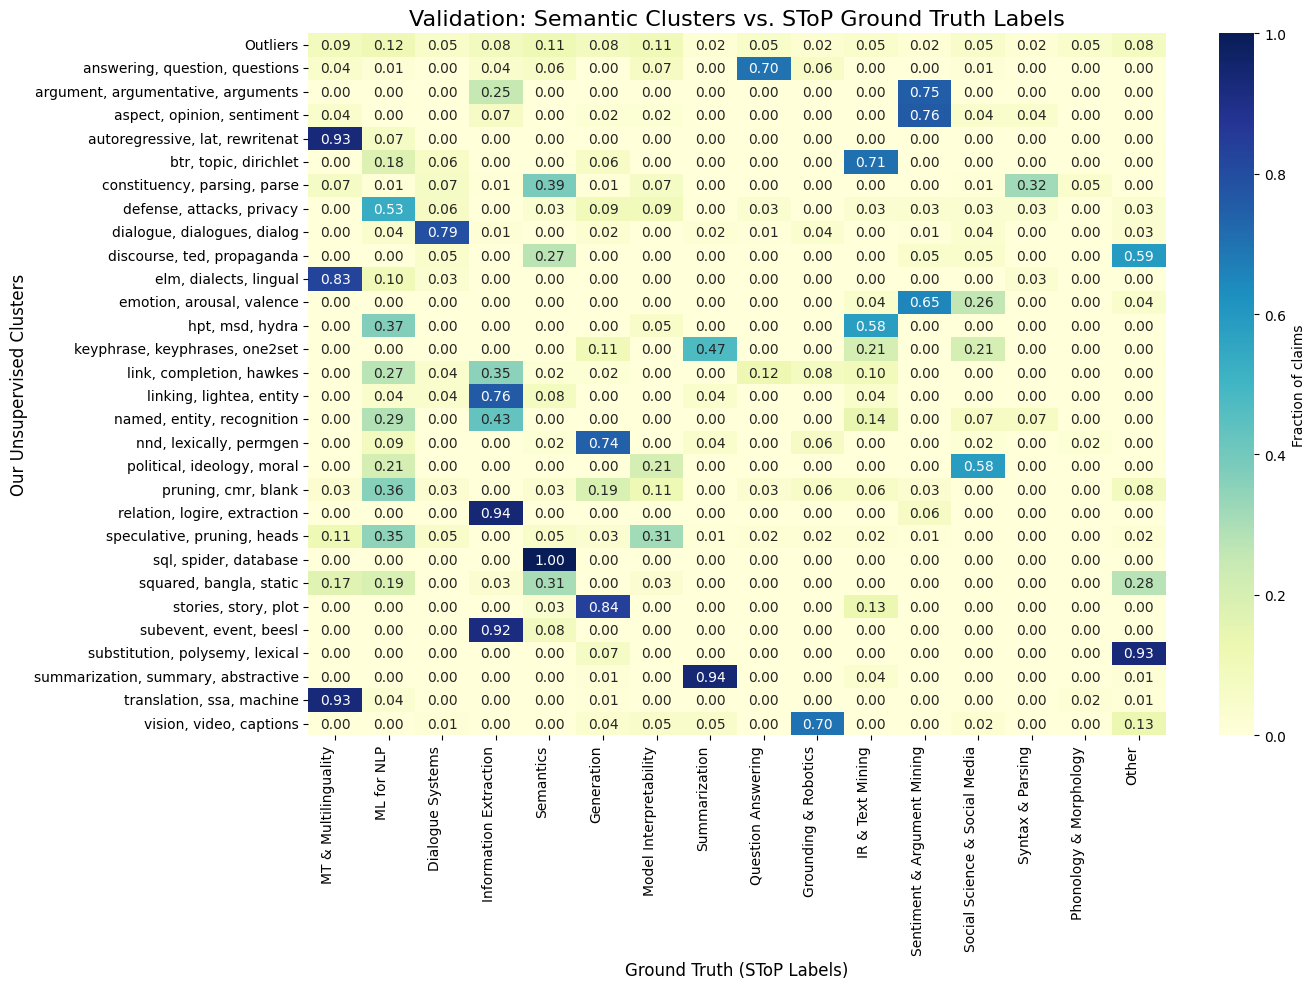

In [27]:
if not (HAS_STOP):
    print('[skipped] depends on data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Filter out noise (-1) for thematic validation
    df_val_clean = df_val[df_val['cluster'] != -1]

    # Add back cluster -1 for completeness
    df_val_clean = pd.concat([df_val_clean, df_val[df_val['cluster'] == -1]])

    # Keep only largest clusters
    cluster_counts = df_val_clean['cluster_name'].value_counts()
    top_clusters = cluster_counts.head(30).index
    df_val_clean = df_val_clean[df_val_clean['cluster_name'].isin(top_clusters)]

    # Keep major themes for visualization
    theme_counts = df_val_clean['Labels'].value_counts()
    top_themes = theme_counts.head(15).index

    # Group all remaining themes into "Other"
    df_val_clean['Labels'] = df_val_clean['Labels'].apply(lambda x: x if x in top_themes else 'Other')
    top_themes = list(top_themes) + ['Other']
    df_val_clean = df_val_clean[df_val_clean['Labels'].isin(top_themes)]

    # Crosstab: rows = our clusters, columns = SToP labels
    ct = pd.crosstab(
        df_val_clean['cluster_name'], 
        df_val_clean['Labels'], 
        normalize='index'
        ).reindex(columns=top_themes,fill_value=0)

    # ct = ct.drop(columns=['Other'])  # Optionally hide "Other"

    # Visualization
    plt.figure(figsize=(14, 10))
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Fraction of claims'})
    plt.title("Validation: Semantic Clusters vs. SToP Ground Truth Labels", fontsize=16)
    plt.xlabel("Ground Truth (SToP Labels)", fontsize=12)
    plt.ylabel("Our Unsupervised Clusters", fontsize=12)
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()

    plt.savefig("artifacts/validation_heatmap.pdf")
    plt.show()

In [28]:
if not (HAS_STOP):
    print('[skipped] depends on data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    def calculate_cluster_purity(df):
        # For each cluster, find the most frequent GT label and its share
        purities = []
        cluster_stats = df.groupby('cluster_name')
    
        for name, group in cluster_stats:
            most_frequent_label_count = group['Labels'].value_counts().iloc[0]
            total_count = len(group)
            purity = most_frequent_label_count / total_count
            main_label = group['Labels'].value_counts().index[0]
        
            purities.append({
                "Cluster": name,
                "Purity": purity,
                "Main GT Label": main_label,
                "Size": total_count
            })
    
        return pd.DataFrame(purities).sort_values('Purity', ascending=False)

    purity_report = calculate_cluster_purity(df_val_clean)

    print("=== CLUSTER PURITY REPORT ===")
    print(purity_report.to_string(index=False))

    avg_purity = (purity_report['Purity'] * purity_report['Size']).sum() / purity_report['Size'].sum()
    print(f"\nWeighted Average Claim-level Purity: {avg_purity:.4f}")

=== CLUSTER PURITY REPORT ===
                            Cluster   Purity                 Main GT Label  Size
              sql, spider, database 1.000000                     Semantics    18
summarization, summary, abstractive 0.939024                 Summarization    82
       relation, logire, extraction 0.937500        Information Extraction    16
    substitution, polysemy, lexical 0.933333                         Other    15
    autoregressive, lat, rewritenat 0.933333          MT & Multilinguality    15
          translation, ssa, machine 0.929825          MT & Multilinguality   114
             subevent, event, beesl 0.916667        Information Extraction    48
               stories, story, plot 0.838710                    Generation    31
             elm, dialects, lingual 0.827586          MT & Multilinguality    29
        dialogue, dialogues, dialog 0.790419              Dialogue Systems   167
         aspect, opinion, sentiment 0.760870   Sentiment & Argument Mining    4

In [29]:
if not (HAS_STOP):
    print('[skipped] depends on data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # 1) Global Metrics for HDBSCAN vs SToP labels
    from sklearn.metrics.cluster import contingency_matrix
    from sklearn.metrics import v_measure_score, adjusted_rand_score
    import numpy as np

    # Reuse existing labels if already prepared; otherwise derive from validation dataframe
    if 'y_true' in globals() and 'y_pred' in globals():
        y_true_eval = np.asarray(y_true)
        y_pred_eval = np.asarray(y_pred)
    else:
        y_true_eval = df_val_clean['Labels'].to_numpy()
        # Prefer numeric cluster id if available, fallback to cluster name
        if 'cluster' in df_val_clean.columns:
            y_pred_eval = df_val_clean['cluster'].to_numpy()
        else:
            y_pred_eval = df_val_clean['cluster_name'].to_numpy()

    cm = contingency_matrix(y_true_eval, y_pred_eval)
    purity = np.max(cm, axis=0).sum() / cm.sum()
    v_measure = v_measure_score(y_true_eval, y_pred_eval)
    ari = adjusted_rand_score(y_true_eval, y_pred_eval)

    print(f"Purity: {purity:.3f}")
    print(f"V-Measure: {v_measure:.3f}")
    print(f"Adjusted Rand Index: {ari:.3f}")

Purity: 0.469
V-Measure: 0.403
Adjusted Rand Index: 0.108


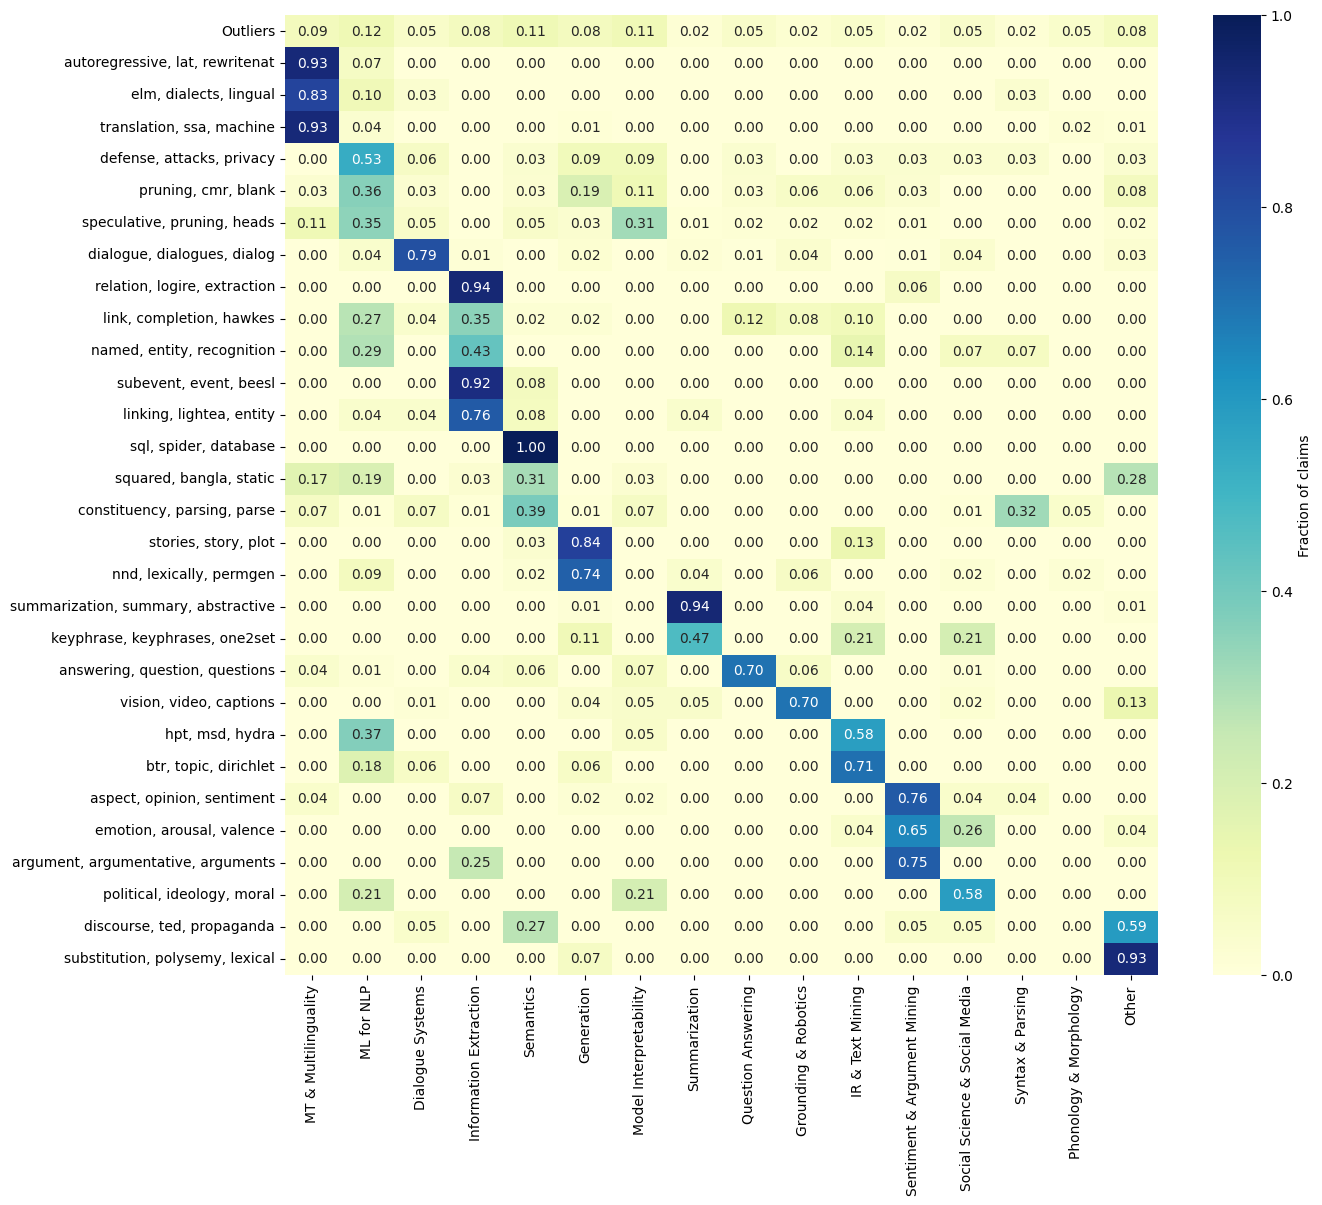

In [31]:
if not (HAS_STOP):
    print('[skipped] depends on data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # 2) Diagonal Heatmap (row reorder to align maxima toward diagonal)
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Reuse overlap_df if it exists; otherwise use the already-created crosstab `ct`
    overlap_src = overlap_df.copy() if 'overlap_df' in globals() else ct.copy()

    row_argmax = overlap_src.to_numpy().argmax(axis=1)
    row_order = np.argsort(row_argmax)

    # Keep the Outliers row fixed at the top of the overlap heatmap.
    outlier_pos = np.flatnonzero([
        str(idx).strip().lower() == 'outliers'
        for idx in overlap_src.index
    ])

    if len(outlier_pos) > 0:
        outlier_set = set(outlier_pos)
        row_order = np.array(
            list(outlier_pos) + [i for i in row_order if i not in outlier_set],
            dtype=int,
        )

    if len(outlier_pos) > 0:
        outlier_set = set(outlier_pos)
        row_order = np.array(
            list(outlier_pos) + [i for i in row_order if i not in outlier_set],
            dtype=int,
        )

    overlap_diag = overlap_src.iloc[row_order]

    plt.figure(figsize=(14, 10))
    ax = sns.heatmap(overlap_diag, cmap='YlGnBu', annot=True, fmt='.2f', cbar_kws={'label': 'Fraction of claims'}, xticklabels=True, yticklabels=True)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.subplots_adjust(top=0.98, bottom=0.02, left=0.02, right=0.8)
    plt.savefig("artifacts/heatmap_overlap.pdf", format='pdf', dpi=300, bbox_inches='tight', pad_inches=0.01)
    plt.show()

    # Optional: keep for reuse in subsequent cells
    overlap_df = overlap_diag

In [32]:
if not (HAS_STOP):
    print('[skipped] depends on data/external SToP taxonomy (absent in the public bundle) — see README §Data')
else:
    # 3) Top-N Mapping Table (Top 10 largest predicted clusters by cluster_name)
    import pandas as pd
    import numpy as np

    # Always use human-readable cluster names from validation dataframe
    eval_df = (
        df_val_clean[['cluster_name', 'Labels']]
        .rename(columns={'cluster_name': 'cluster_label', 'Labels': 'y_true'})
        .dropna()
        .copy()
    )

    # Optional: exclude outliers/noise from Top-N
    if 'cluster' in df_val_clean.columns:
        eval_df_no_noise = eval_df[df_val_clean.loc[eval_df.index, 'cluster'] != -1].copy()
    else:
        eval_df_no_noise = eval_df[eval_df['cluster_label'].astype(str).str.lower() != 'outliers'].copy()

    top_clusters = eval_df_no_noise['cluster_label'].value_counts().head(10)
    rows = []

    for cluster_label, cluster_size in top_clusters.items():
        subset = eval_df_no_noise[eval_df_no_noise['cluster_label'] == cluster_label]
        gt_counts = subset['y_true'].value_counts()
        mapped_category = gt_counts.index[0]
        purity_pct = (gt_counts.iloc[0] / len(subset)) * 100

        rows.append({
            'Cluster': cluster_label,
            'Cluster Size': int(cluster_size),
            'Mapped Category': mapped_category,
            'Purity (%)': round(purity_pct, 3),
        })

    top_mapping_df = pd.DataFrame(rows).sort_values('Cluster Size', ascending=False).reset_index(drop=True)

    print(top_mapping_df)
    print('\nLaTeX:')
    print(top_mapping_df.to_latex(index=False, float_format='%.3f', escape=True))

                               Cluster  Cluster Size         Mapped Category  \
0          dialogue, dialogues, dialog           167        Dialogue Systems   
1          speculative, pruning, heads           115              ML for NLP   
2            translation, ssa, machine           114    MT & Multilinguality   
3         constituency, parsing, parse            88               Semantics   
4              vision, video, captions            83    Grounding & Robotics   
5  summarization, summary, abstractive            82           Summarization   
6       answering, question, questions            70      Question Answering   
7             link, completion, hawkes            51  Information Extraction   
8               subevent, event, beesl            48  Information Extraction   
9              nnd, lexically, permgen            47              Generation   

   Purity (%)  
0      79.042  
1      34.783  
2      92.982  
3      38.636  
4      69.880  
5      93.902  
6      